<a href="https://colab.research.google.com/github/shishir881/Kamala-River-WaterLevel-Detection-RAN/blob/main/Kamala_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
import warnings
warnings.filterwarnings('ignore')

print("--- Step 1: Preparing 3D Data for LSTM ---")

# 1. Load Data
df = pd.read_csv('/content/kamala_mvp_dataset.csv', parse_dates=['Date'], index_col='Date')

# 2. Define Features (All 14 columns) and Targets (Last 2 columns)
all_features = df.columns
target_cols = ['discharge_m3s', 'river_height_m']

# 3. Train/Test Split (Chronological)
train_df = df.loc['2016-01-01':'2018-12-31']
test_df = df.loc['2019-01-01':'2019-12-31']

# 4. Scaling (0 to 1)
scaler_X = MinMaxScaler(feature_range=(0, 1))
scaler_y = MinMaxScaler(feature_range=(0, 1))

train_X_scaled = scaler_X.fit_transform(train_df[all_features])
train_y_scaled = scaler_y.fit_transform(train_df[target_cols])

test_X_scaled = scaler_X.transform(test_df[all_features])
test_y_scaled = scaler_y.transform(test_df[target_cols])

# 5. Sliding Window Function
def create_sequences(X_data, y_data, time_steps):
    X, y = [], []
    for i in range(len(X_data) - time_steps):
        X.append(X_data[i : (i + time_steps)])
        y.append(y_data[i + time_steps])
    return np.array(X), np.array(y)

# We use 7 days of past data to predict tomorrow
LOOKBACK = 14

X_train, y_train = create_sequences(train_X_scaled, train_y_scaled, LOOKBACK)
X_test, y_test = create_sequences(test_X_scaled, test_y_scaled, LOOKBACK)

print(f"Ready! Training shapes -> X: {X_train.shape}, y: {y_train.shape}")
print(f"Testing shapes  -> X: {X_test.shape}, y: {y_test.shape}")

--- Step 1: Preparing 3D Data for LSTM ---
Ready! Training shapes -> X: (1082, 14, 14), y: (1082, 2)
Testing shapes  -> X: (351, 14, 14), y: (351, 2)


In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

print("--- Step 1: Building the Advanced LSTM Architecture ---")

# Initialize the model
model = Sequential()

# Layer 1: Main LSTM memory block (128 neurons for complex patterns)
model.add(LSTM(units=128, return_sequences=True, input_shape=(X_train.shape[1], X_train.shape[2])))
model.add(Dropout(0.2))

# Layer 2: Refinement block (64 neurons)
model.add(LSTM(units=64, return_sequences=False))
model.add(Dropout(0.2))

# Layer 3: Intermediate processing
model.add(Dense(units=32, activation='relu'))

# Output Layer: 2 outputs (Discharge and Height)
model.add(Dense(units=2))

# Compile using Huber loss (Great for handling extreme flood peaks!)
model.compile(optimizer='adam', loss=tf.keras.losses.Huber())

model.summary()
print("\nModel Architecture is Ready!")

--- Step 1: Building the Advanced LSTM Architecture ---


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 14, 128)        │        73,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 14, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 2)              │            66 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 124,770 (487.38 KB)

 Trainable params: 124,770 (487.38 KB)

 Non-trainable params: 0 (0.00 B)


Model Architecture is Ready!


--- Step 2: Training the Model ---
Epoch 1/100
61/61 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - loss: 0.0052 - val_loss: 4.4838e-04
Epoch 2/100
61/61 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0025 - val_loss: 5.5043e-04
Epoch 3/100
61/61 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0022 - val_loss: 6.2124e-04
Epoch 4/100
61/61 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0021 - val_loss: 7.3156e-04
Epoch 5/100
61/61 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0023 - val_loss: 9.0666e-04
Epoch 6/100
61/61 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0018 - val_loss: 4.6222e-04
Epoch 7/100
61/61 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0016 - val_loss: 5.7135e-04
Epoch 8/100
61/61 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0017 - val_loss: 6.4824e-04
Epoch 9/100
61/61 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0017 - val_loss: 6.5451e-04
Epoch 10/100
61/61 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0016 - val_loss: 7.6449e-04
Epoch 11/100
61/61 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0016 -

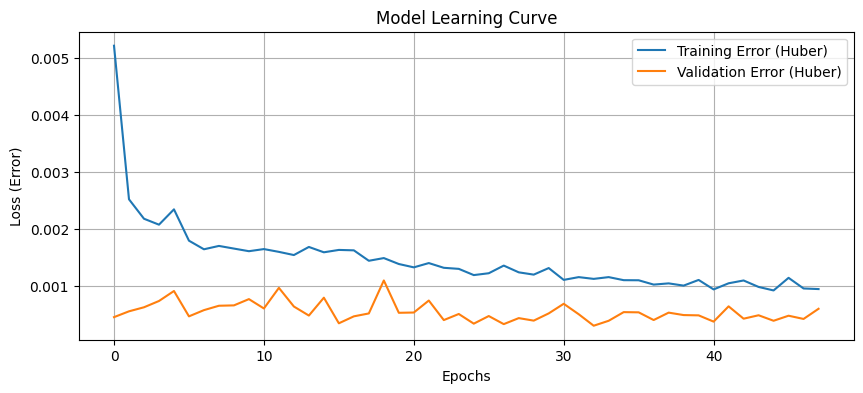


Training Complete! Model weights are saved in memory.


In [ ]:
from tensorflow.keras.callbacks import EarlyStopping
import matplotlib.pyplot as plt

print("--- Step 2: Training the Model ---")

# Stop early if validation loss doesn't improve for 15 epochs
early_stop = EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True)

# Train the model
history = model.fit(
    X_train, y_train,
    epochs=100,            # Let it run up to 100 times
    batch_size=16,
    validation_split=0.1,  # Keep 10% data for mini-tests
    callbacks=[early_stop],
    verbose=1
)

# Plot the Learning Curve
plt.figure(figsize=(10, 4))
plt.plot(history.history['loss'], label='Training Error (Huber)')
plt.plot(history.history['val_loss'], label='Validation Error (Huber)')
plt.title('Model Learning Curve')
plt.xlabel('Epochs')
plt.ylabel('Loss (Error)')
plt.legend()
plt.grid(True)
plt.show()

print("\nTraining Complete! Model weights are saved in memory.")

--- Step 3: Prediction & Accuracy Evaluation (2019 Unseen Data) ---
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step

=== FINAL ACCURACY REPORT (RIVER DISCHARGE) ===
MSE:  1388.98
RMSE: 37.27 m³/s
MAE:  18.03 m³/s
R² Score: 76.25%


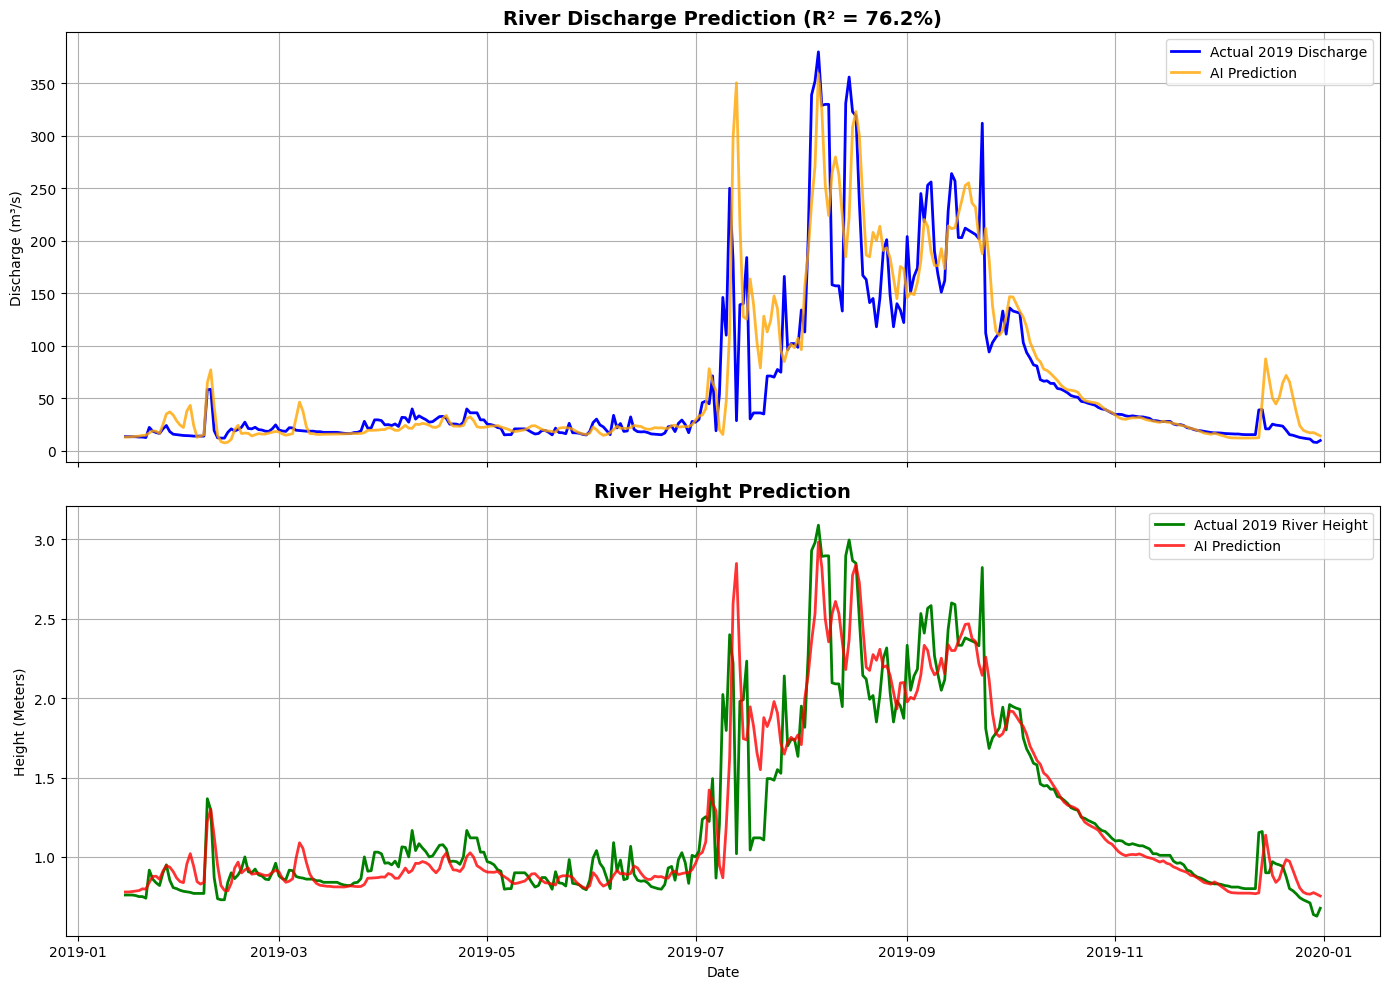

In [ ]:
import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import matplotlib.pyplot as plt

print("--- Step 3: Prediction & Accuracy Evaluation (2019 Unseen Data) ---")

# 1. Generate Predictions
predictions_scaled = model.predict(X_test)

# 2. Reverse the scaling to get actual m³/s and meters
predictions_real = scaler_y.inverse_transform(predictions_scaled)
y_test_real = scaler_y.inverse_transform(y_test)

# Extract Discharge parameters
actual_discharge = y_test_real[:, 0]
predicted_discharge = predictions_real[:, 0]

# Extract Height parameters
actual_height = y_test_real[:, 1]
predicted_height = predictions_real[:, 1]

# 3. Calculate Accuracy Metrics for Discharge
mse = mean_squared_error(actual_discharge, predicted_discharge)
rmse = np.sqrt(mse)
mae = mean_absolute_error(actual_discharge, predicted_discharge)
r2 = r2_score(actual_discharge, predicted_discharge)

print("\n=== FINAL ACCURACY REPORT (RIVER DISCHARGE) ===")
print(f"MSE:  {mse:.2f}")
print(f"RMSE: {rmse:.2f} m³/s")
print(f"MAE:  {mae:.2f} m³/s")
print(f"R² Score: {r2*100:.2f}%")

# 4. Plotting the Results
plot_dates = test_df.index[LOOKBACK:]

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10), sharex=True)

# Plot Discharge
ax1.plot(plot_dates, actual_discharge, label='Actual 2019 Discharge', color='blue', linewidth=2)
ax1.plot(plot_dates, predicted_discharge, label='AI Prediction', color='orange', linewidth=2, alpha=0.8)
ax1.set_title(f'River Discharge Prediction (R² = {r2*100:.1f}%)', fontsize=14, fontweight='bold')
ax1.set_ylabel('Discharge (m³/s)')
ax1.legend()
ax1.grid(True)

# Plot Height
ax2.plot(plot_dates, actual_height, label='Actual 2019 River Height', color='green', linewidth=2)
ax2.plot(plot_dates, predicted_height, label='AI Prediction', color='red', linewidth=2, alpha=0.8)
ax2.set_title('River Height Prediction', fontsize=14, fontweight='bold')
ax2.set_ylabel('Height (Meters)')
ax2.set_xlabel('Date')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()

In [ ]:
import joblib
import os

print("--- Step 5: Exporting Model & Scalers for Production ---")

# 1. Define paths for saving (Updated for Colab)
model_path = '/content/kamala_flood_lstm_v2.h5'
scaler_X_path = '/content/scaler_X.pkl'
scaler_y_path = '/content/scaler_y.pkl'

# 2. Save the Trained Neural Network (The Brain)
model.save(model_path)
print(f"✅ Model saved successfully at: {model_path}")

# 3. Save the Scalers (The Translators)
# THIS IS CRITICAL! Without these, your frontend won't know how to scale new weather data
joblib.dump(scaler_X, scaler_X_path)
print(f"✅ Input Scaler (X) saved at: {scaler_X_path}")

joblib.dump(scaler_y, scaler_y_path)
print(f"✅ Output Scaler (y) saved at: {scaler_y_path}")

print("\n🎉 CONGRATULATIONS! Your AI Model is now ready to be deployed to your Backend/Frontend!")

--- Step 5: Exporting Model & Scalers for Production ---
✅ Model saved successfully at: /content/kamala_flood_lstm_v2.h5
✅ Input Scaler (X) saved at: /content/scaler_X.pkl
✅ Output Scaler (y) saved at: /content/scaler_y.pkl

🎉 CONGRATULATIONS! Your AI Model is now ready to be deployed to your Backend/Frontend!
